# Evaluation Pipeline — V6

Pipeline under evaluation:
```
Stage 1  → Groq LLM rewrites raw ticket                                     (call #1 — gated by confidence)
Stage 2a → Fine-tuned DistilBERT V6: dept + priority classification          (no API, always)
Stage 2b → Hybrid RAG: all-MiniLM-L6-v2 → FAISS+BM25+RRF+BGE reranker      (no API, gated)
Stage 3  → Groq LLM decides dept + priority from all 3 sources              (call #2 — gated)
```

| Section | What | API calls |
|---|---|---|
| 1 | Transformer standalone — accuracy, F1, calibration, ECE | None |
| 2 | RAG retrieval — Recall@K, MRR, CE distributions | None |
| 3 | Full pipeline — accuracy, LLM override rate, TTFT, TPOT | 2/ticket |
| 4 | AI-as-a-judge — rewrite quality, reasoning quality, routing quality | 3/ticket |

**Resume support:** every section caches results to `outputs/evaluation/`. Rerun any cell to resume.

**Token rotation:** add up to 6 keys in `secrets.env` as `GROQ_API_KEY`, `GROQ_API_KEY_2` ... `GROQ_API_KEY_6`.

In [2]:
import os, sys, time, json, re, warnings, pickle, math
warnings.filterwarnings('ignore')

ROOT = os.path.abspath('.')
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

OUT_DIR = os.path.join(ROOT, 'outputs', 'evaluation')
os.makedirs(OUT_DIR, exist_ok=True)

TRANSFORMER_RESULTS_PATH = os.path.join(OUT_DIR, 'transformer_results.csv')
RAG_RESULTS_PATH         = os.path.join(OUT_DIR, 'rag_retrieval_results.csv')
PIPELINE_RESULTS_PATH    = os.path.join(OUT_DIR, 'pipeline_results.csv')
JUDGE_RESULTS_PATH       = os.path.join(OUT_DIR, 'judge_results.csv')

from dotenv import load_dotenv
load_dotenv()
# load_dotenv(os.path.join(ROOT, 'secrets.env'))
HF_TOKEN = os.getenv('HF_TOKEN')

# ── Token rotation ─────────────────────────────────────────────────────
import groq as _groq_mod
from groq import Groq, RateLimitError

# _raw_tokens = [
#     os.getenv('GROQ_API_KEY',   ''),
#     os.getenv('GROQ_API_KEY_2', ''),
#     os.getenv('GROQ_API_KEY_3', ''),
#     os.getenv('GROQ_API_KEY_4', ''),
#     os.getenv('GROQ_API_KEY_5', ''),
#     os.getenv('GROQ_API_KEY_6', ''),
# ]
# GROQ_TOKENS = [t for t in _raw_tokens if t.startswith('gsk_')]
assert HF_TOKEN and HF_TOKEN.startswith('hf_'), 'HF_TOKEN missing'
# assert GROQ_TOKENS, 'No GROQ tokens found'

class TokenRotator:
    def __init__(self, tokens):
        self.tokens    = tokens
        self.idx       = 0
        self.client    = Groq(api_key=tokens[0])
        self.exhausted = False

    def call(self, model, messages, temperature=0.0, max_tokens=500):
        while self.idx < len(self.tokens):
            try:
                r = self.client.chat.completions.create(
                    model=model, messages=messages,
                    temperature=temperature, max_tokens=max_tokens)
                return r.choices[0].message.content.strip()
            except RateLimitError:
                self.idx += 1
                if self.idx < len(self.tokens):
                    print(f'  ⚠ Token exhausted — switching to token {self.idx+1}')
                    self.client = Groq(api_key=self.tokens[self.idx])
                else:
                    self.exhausted = True
                    print('  ✗ All tokens exhausted')
                    return None
            except Exception as e:
                print(f'  ⚠ API error: {e}')
                return None
        self.exhausted = True
        return None


class RotatingGroqClient:
    """
    Wraps TokenRotator so it looks like a Groq client to route_ticket,
    stage1_rewriter, and stage3_generator — which all call
    groq_client.chat.completions.create(...) internally.
    Rotation happens automatically on every 429.
    """
    def __init__(self, rotator):
        self.rotator     = rotator
        self.chat        = self
        self.completions = self

    def create(self, model, messages, temperature=0.0, max_tokens=500, **kwargs):
        while self.rotator.idx < len(self.rotator.tokens):
            try:
                return self.rotator.client.chat.completions.create(
                    model=model, messages=messages,
                    temperature=temperature, max_tokens=max_tokens
                )
            except RateLimitError:
                self.rotator.idx += 1
                if self.rotator.idx < len(self.rotator.tokens):
                    print(f'  ⚠ Token exhausted — switching to token {self.rotator.idx+1}')
                    self.rotator.client = Groq(api_key=self.rotator.tokens[self.rotator.idx])
                else:
                    self.rotator.exhausted = True
                    raise RateLimitError('All tokens exhausted')
        raise RateLimitError('All tokens exhausted')


# rotator     = TokenRotator(GROQ_TOKENS)
# groq_client = RotatingGroqClient(rotator)   # pipeline calls rotate automatically on 429

# print(f'{len(GROQ_TOKENS)} Groq token(s) loaded')
print(f'Outputs: {OUT_DIR}')

Outputs: /Users/avani/IdeaProjects/customer-support-management/outputs/evaluation


In [3]:
import torch
import pandas as pd
import numpy as np
import joblib
import faiss
from tqdm import tqdm
from huggingface_hub import hf_hub_download
from transformers import AutoTokenizer, AutoModel
from sentence_transformers import SentenceTransformer, CrossEncoder
from rank_bm25 import BM25Okapi

from pipeline.stage2a_transformer import MultiTaskModel, clean_text, transformer_predict
from pipeline.stage2b_retriever   import hybrid_retrieve, retrieve_priority_chunk
from pipeline.stage1_rewriter     import rewrite_query as _stage1
from pipeline.router               import route_ticket

TRANSFORMER_ID = 'Nethra19/multitask-ticket-model-v6'
RAG_REPO_ID    = 'Nethra19/rag-index-v6'
STAGE3_MODEL   = 'meta-llama/llama-4-scout-17b-16e-instruct'
JUDGE_MODEL    = 'meta-llama/llama-4-scout-17b-16e-instruct'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = 'mps'
print(f'Device: {device}')

print('Loading V6 transformer...')
tokenizer        = AutoTokenizer.from_pretrained(TRANSFORMER_ID, token=HF_TOKEN)
queue_encoder    = joblib.load(hf_hub_download(TRANSFORMER_ID, 'queue_encoder.pkl',    token=HF_TOKEN))
priority_encoder = joblib.load(hf_hub_download(TRANSFORMER_ID, 'priority_encoder.pkl', token=HF_TOKEN))
model = MultiTaskModel(TRANSFORMER_ID, len(queue_encoder.classes_), len(priority_encoder.classes_))
heads = torch.load(hf_hub_download(TRANSFORMER_ID, 'heads.pt', token=HF_TOKEN),
                   map_location=device, weights_only=False)
model.queue_classifier.load_state_dict(heads['queue_classifier'])
model.priority_classifier.load_state_dict(heads['priority_classifier'])
model.to(device).eval()
print('  Transformer ready')

print('Loading RAG artifacts...')
faiss_index = faiss.read_index(
    hf_hub_download(RAG_REPO_ID, 'rag_compliance_index.faiss', token=HF_TOKEN, repo_type='model'))
with open(hf_hub_download(RAG_REPO_ID, 'rag_bm25_index.pkl', token=HF_TOKEN, repo_type='model'), 'rb') as f:
    bm25 = pickle.load(f)['bm25']
with open(hf_hub_download(RAG_REPO_ID, 'rag_compliance_metadata.pkl', token=HF_TOKEN, repo_type='model'), 'rb') as f:
    all_chunks = pickle.load(f)
priority_index = faiss.read_index(
    hf_hub_download(RAG_REPO_ID, 'rag_priority_index.faiss', token=HF_TOKEN, repo_type='model'))
with open(hf_hub_download(RAG_REPO_ID, 'rag_priority_metadata.pkl', token=HF_TOKEN, repo_type='model'), 'rb') as f:
    priority_chunks = pickle.load(f)
embedder      = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
cross_encoder = CrossEncoder('BAAI/bge-reranker-base')
print(f'  RAG ready: {faiss_index.ntotal} dept vectors')
print('\n✓ All components ready')

Device: mps
Loading V6 transformer...


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 36928.19it/s]


  Transformer ready
Loading RAG artifacts...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9625.97it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 10737.64it/s]
XLMRobertaForSequenceClassification LOAD REPORT from: BAAI/bge-reranker-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  RAG ready: 72 dept vectors

✓ All components ready


In [4]:
test_df = pd.read_csv('./outputs/test_clean_v2.csv')
# text column is already body-only, cleaned
test_df['raw_text'] = test_df['text'].fillna('').str.strip()

print(f'Test set: {len(test_df)} tickets')
print(test_df['queue'].value_counts())

# 30 per dept for Sections 1+2 — no API cost
eval_df = pd.concat([
    group.sample(min(len(group), 30), random_state=42)
    for _, group in test_df.groupby('queue')
]).reset_index(drop=True)

# 10 per dept for Sections 3+4 — Groq calls
pipeline_df = pd.concat([
    group.sample(min(len(group), 24), random_state=42)
    for _, group in test_df.groupby('queue')
]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f'\nEval sample (Sec 1+2): {len(eval_df)} | Pipeline sample (Sec 3+4): {len(pipeline_df)}')

Test set: 192 tickets
queue
Billing and Payments               24
Customer Service                   24
General Inquiry                    24
Human Resources                    24
Returns and Exchanges              24
Sales and Pre-Sales                24
Service Outages and Maintenance    24
Technical & IT Support             24
Name: count, dtype: int64

Eval sample (Sec 1+2): 192 | Pipeline sample (Sec 3+4): 192


---
## Section 1 — Transformer Standalone (Stage 2a)
No API calls. DistilBERT V6 classifier in isolation — baseline before RAG or LLM.

In [5]:
if os.path.exists(TRANSFORMER_RESULTS_PATH):
    trans_df = pd.read_csv(TRANSFORMER_RESULTS_PATH)
    print(f'Loaded cached transformer results ({len(trans_df)} rows)')
else:
    records = []
    for _, row in tqdm(eval_df.iterrows(), total=len(eval_df)):
        r = transformer_predict(
            row['raw_text'], model, tokenizer, queue_encoder, priority_encoder, device
        )
        records.append({
            'true_dept'    : row['queue'],    'true_priority': row['priority'],
            'pred_dept'    : r['dept'],        'dept_conf'    : r['dept_conf'],
            'pred_priority': r['priority'],    'priority_conf': r['priority_conf'],
        })
    trans_df = pd.DataFrame(records)
    trans_df.to_csv(TRANSFORMER_RESULTS_PATH, index=False)
    print(f'Saved {len(trans_df)} rows')

Loaded cached transformer results (192 rows)


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

dept_acc = accuracy_score(trans_df['true_dept'],     trans_df['pred_dept'])
dept_f1  = f1_score(trans_df['true_dept'],     trans_df['pred_dept'],     average='macro', zero_division=0)
prio_acc = accuracy_score(trans_df['true_priority'], trans_df['pred_priority'])
prio_f1  = f1_score(trans_df['true_priority'], trans_df['pred_priority'], average='macro', zero_division=0)

print('=' * 55)
print('TRANSFORMER STANDALONE (V6)')
print('=' * 55)
print(f'Dept  Accuracy: {dept_acc*100:.1f}%  Macro F1: {dept_f1*100:.1f}%')
print(f'Prio  Accuracy: {prio_acc*100:.1f}%  Macro F1: {prio_f1*100:.1f}%')
print()
print('DEPARTMENT REPORT:')
print(classification_report(trans_df['true_dept'], trans_df['pred_dept'], zero_division=0))
print('PRIORITY REPORT:')
print(classification_report(trans_df['true_priority'], trans_df['pred_priority'], zero_division=0))

TRANSFORMER STANDALONE (V6)
Dept  Accuracy: 58.9%  Macro F1: 52.4%
Prio  Accuracy: 39.1%  Macro F1: 29.0%

DEPARTMENT REPORT:
                                 precision    recall  f1-score   support

           Billing and Payments       0.92      1.00      0.96        24
               Customer Service       0.50      0.04      0.08        24
                General Inquiry       0.20      0.04      0.07        24
                Human Resources       0.53      1.00      0.70        24
          Returns and Exchanges       0.53      0.79      0.63        24
            Sales and Pre-Sales       0.43      0.88      0.58        24
Service Outages and Maintenance       0.82      0.58      0.68        24
         Technical & IT Support       0.75      0.38      0.50        24

                       accuracy                           0.59       192
                      macro avg       0.59      0.59      0.52       192
                   weighted avg       0.59      0.59      0.52       

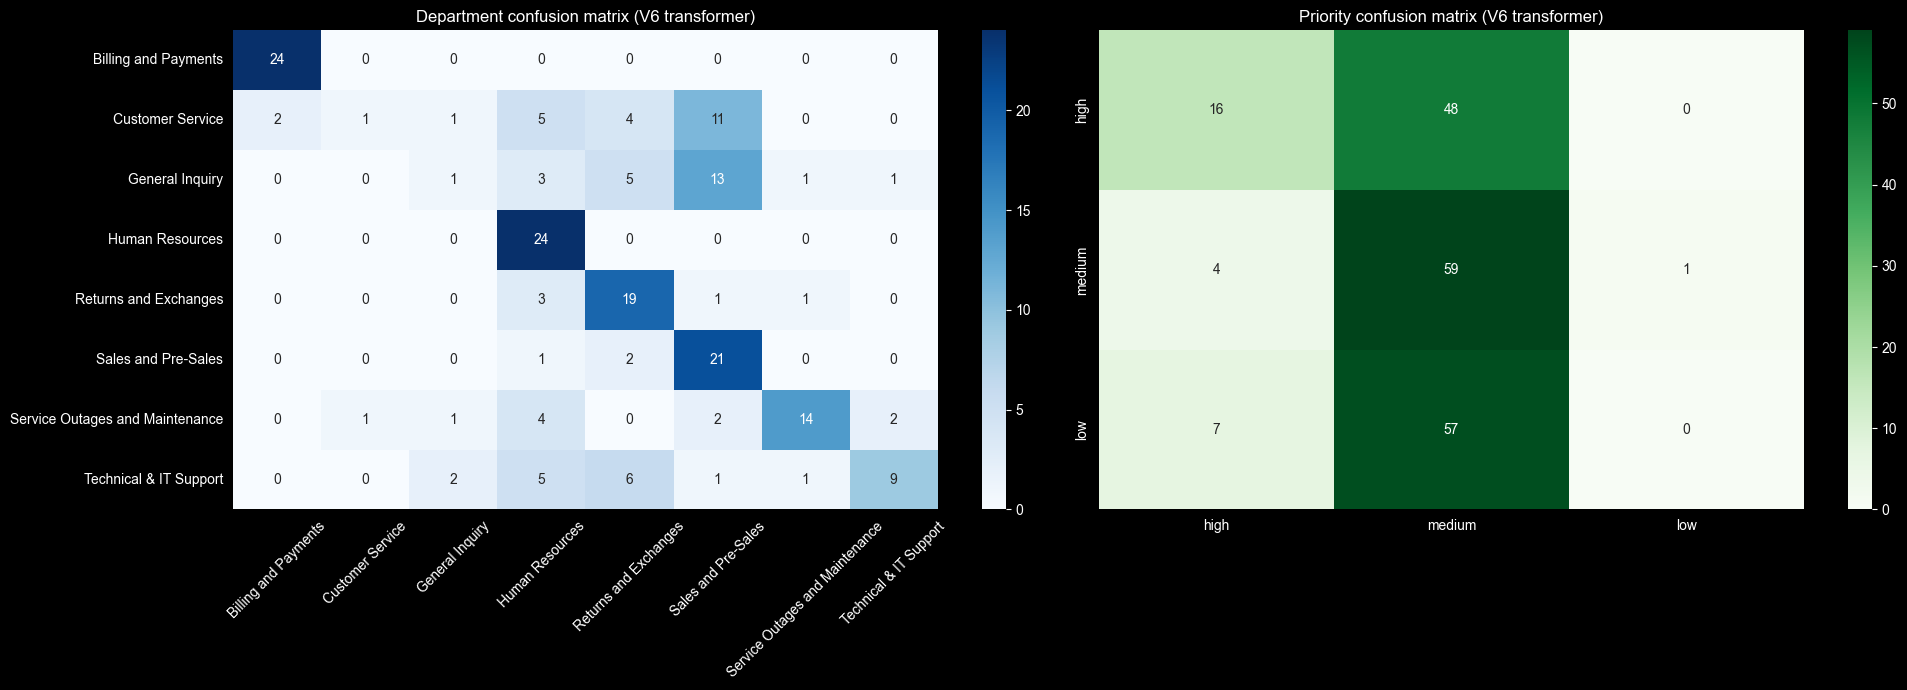

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
dept_labels = sorted(trans_df['true_dept'].unique())
prio_labels = ['high', 'medium', 'low']

sns.heatmap(confusion_matrix(trans_df['true_dept'], trans_df['pred_dept'], labels=dept_labels),
    annot=True, fmt='d', cmap='Blues',
    xticklabels=dept_labels, yticklabels=dept_labels, ax=axes[0])
axes[0].set_title('Department confusion matrix (V6 transformer)')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(confusion_matrix(trans_df['true_priority'], trans_df['pred_priority'], labels=prio_labels),
    annot=True, fmt='d', cmap='Greens',
    xticklabels=prio_labels, yticklabels=prio_labels, ax=axes[1])
axes[1].set_title('Priority confusion matrix (V6 transformer)')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'transformer_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

Department ECE: 0.1578  |  Priority ECE: 0.4078  (lower = better calibrated)


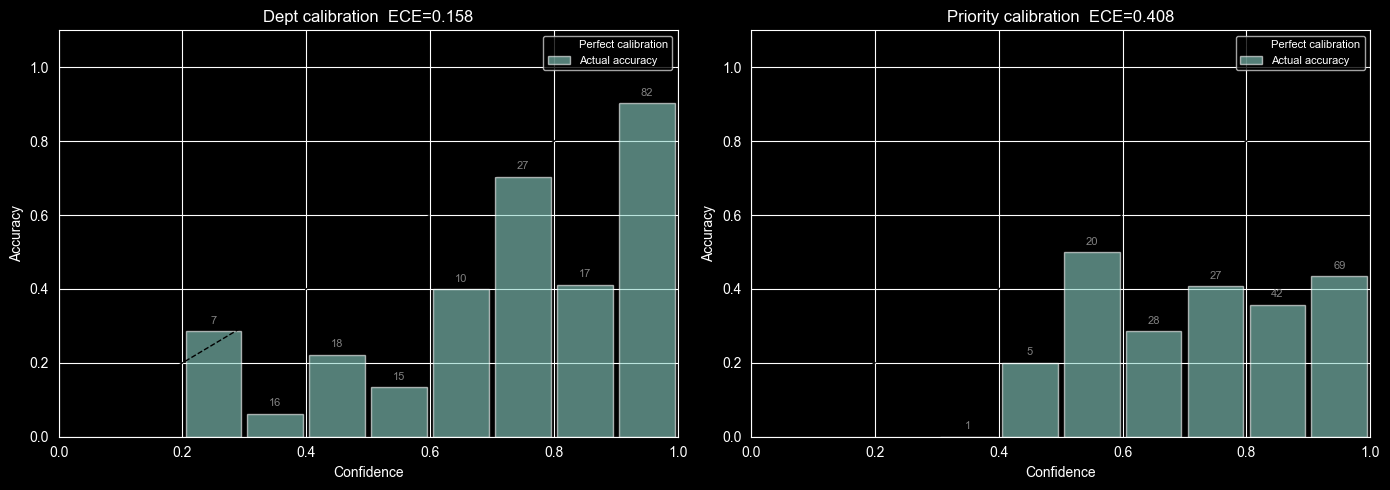

In [8]:
# Confidence calibration + ECE
def calibration_data(df, conf_col, correct_col, n=10):
    bins = np.linspace(0, 1, n + 1)
    mids, accs, counts = [], [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        s = df[(df[conf_col] >= lo) & (df[conf_col] < hi)]
        if len(s) == 0: continue
        mids.append((lo+hi)/2); accs.append(s[correct_col].mean()); counts.append(len(s))
    return np.array(mids), np.array(accs), np.array(counts)

def ece(mids, accs, counts):
    return float(np.sum(counts * np.abs(mids - accs)) / counts.sum())

trans_df['dept_correct'] = (trans_df['pred_dept']     == trans_df['true_dept']).astype(int)
trans_df['prio_correct'] = (trans_df['pred_priority'] == trans_df['true_priority']).astype(int)

d_m, d_a, d_c = calibration_data(trans_df, 'dept_conf',     'dept_correct')
p_m, p_a, p_c = calibration_data(trans_df, 'priority_conf', 'prio_correct')
dept_ece = ece(d_m, d_a, d_c)
prio_ece = ece(p_m, p_a, p_c)
print(f'Department ECE: {dept_ece:.4f}  |  Priority ECE: {prio_ece:.4f}  (lower = better calibrated)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, mids, accs, counts, ece_val, title in [
    (axes[0], d_m, d_a, d_c, dept_ece, f'Dept calibration  ECE={dept_ece:.3f}'),
    (axes[1], p_m, p_a, p_c, prio_ece, f'Priority calibration  ECE={prio_ece:.3f}'),
]:
    w = mids[1]-mids[0] if len(mids)>1 else 0.1
    ax.bar(mids, accs, width=w*0.9, alpha=0.6, label='Actual accuracy')
    ax.plot([0,1],[0,1],'k--',lw=1,label='Perfect calibration')
    for m,a,c in zip(mids,accs,counts): ax.text(m,a+0.02,str(c),ha='center',fontsize=8,color='grey')
    ax.set_xlim(0,1); ax.set_ylim(0,1.1)
    ax.set_xlabel('Confidence'); ax.set_ylabel('Accuracy')
    ax.set_title(title); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'calibration_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Section 2 — RAG Retrieval (Stage 2b)
No API calls. Uses `all-MiniLM-L6-v2` embedder + BGE reranker (V6 — fixes domain mismatch).
Evaluates whether the correct dept chunk and priority chunk are retrieved.

In [9]:
import os
import tqdm
if os.path.exists(RAG_RESULTS_PATH):
    rag_df = pd.read_csv(RAG_RESULTS_PATH)
    print(f"Loaded cached RAG results ({len(rag_df)} rows)")

else:
    records = []

    for _, row in tqdm(eval_df.iterrows(), total=len(eval_df)):
        query     = row["raw_text"]
        true_dept = row["queue"]
        true_prio = row["priority"].lower()

        # ---------------------------
        # Dept Retrieval (Stage 2b)
        # ---------------------------
        results, rag_gap = hybrid_retrieve(
            query=query,
            embedder=embedder,
            faiss_index=faiss_index,
            bm25=bm25,
            all_chunks=all_chunks,
            cross_encoder=cross_encoder,
            top_k_dense=10,
            top_k_bm25=10,
            top_n_final=4
        )

        depts  = [r["chunk"]["dept"] for r in results]
        scores = [r["ce_score"] for r in results]

        # Metrics
        r1  = int(depts[0] == true_dept) if depts else 0
        r4  = int(true_dept in depts)
        mrr = next((1.0 / (rank + 1) for rank, d in enumerate(depts) if d == true_dept), 0.0)

        # ---------------------------
        # Priority Retrieval
        # ---------------------------
        prio_res = retrieve_priority_chunk(
            query=query,
            embedder=embedder,
            priority_index=priority_index,
            priority_chunks=priority_chunks,
            cross_encoder=cross_encoder
        )

        if prio_res:
            prio_section = prio_res["chunk"]["section"].lower()
            prio_score   = prio_res["ce_score"]
            prio_correct = int(prio_section == true_prio)
        else:
            prio_section = ""
            prio_score   = 0.0
            prio_correct = 0

        # ---------------------------
        # Store record
        # ---------------------------
        records.append({
            "true_dept"      : true_dept,
            "true_priority"  : true_prio,

            "top1_dept"      : depts[0] if depts else "",
            "recall_at_1"    : r1,
            "recall_at_4"    : r4,
            "mrr"            : mrr,
            "top_ce_score"   : scores[0] if scores else 0.0,
            "rag_gap"        : rag_gap,

            "prio_section"   : prio_section,
            "prio_ce_score"  : prio_score,
            "prio_correct"   : prio_correct,
        })

    rag_df = pd.DataFrame(records)
    rag_df.to_csv(RAG_RESULTS_PATH, index=False)

    print(f"Saved {len(rag_df)} rows")

Loaded cached RAG results (192 rows)


In [10]:
print('=' * 55)
print('RAG RETRIEVAL RESULTS (V6 — all-MiniLM + BGE reranker)')
print('=' * 55)
print(f'Dept  Recall@1 : {rag_df["recall_at_1"].mean()*100:.1f}%')
print(f'Dept  Recall@4 : {rag_df["recall_at_4"].mean()*100:.1f}%')
print(f'Dept  MRR      : {rag_df["mrr"].mean():.3f}')
print(f'Prio  Section  : {rag_df["prio_correct"].mean()*100:.1f}%  (random baseline 33.3%)')
print()
print('Recall@1 per department:')
per_dept = rag_df.groupby('true_dept')['recall_at_1'].agg(['mean','count']).rename(
    columns={'mean':'Recall@1','count':'N'}).sort_values('Recall@1', ascending=False)
per_dept['Recall@1'] = (per_dept['Recall@1']*100).round(1).astype(str)+'%'
print(per_dept)

print(f'\nCE score distribution (after sigmoid):')
print(f'  Mean top CE   : {rag_df["top_ce_score"].mean():.3f}')
print(f'  Median top CE : {rag_df["top_ce_score"].median():.3f}')
print(f'  Min / Max     : {rag_df["top_ce_score"].min():.3f} / {rag_df["top_ce_score"].max():.3f}')

RAG RETRIEVAL RESULTS (V6 — all-MiniLM + BGE reranker)
Dept  Recall@1 : 72.9%
Dept  Recall@4 : 94.8%
Dept  MRR      : 0.822
Prio  Section  : 57.3%  (random baseline 33.3%)

Recall@1 per department:
                                Recall@1   N
true_dept                                   
Billing and Payments              100.0%  24
Human Resources                   100.0%  24
Returns and Exchanges              79.2%  24
Sales and Pre-Sales                70.8%  24
Customer Service                   66.7%  24
Service Outages and Maintenance    66.7%  24
General Inquiry                    62.5%  24
Technical & IT Support             37.5%  24

CE score distribution (after sigmoid):
  Mean top CE   : 0.525
  Median top CE : 0.505
  Min / Max     : 0.500 / 0.727


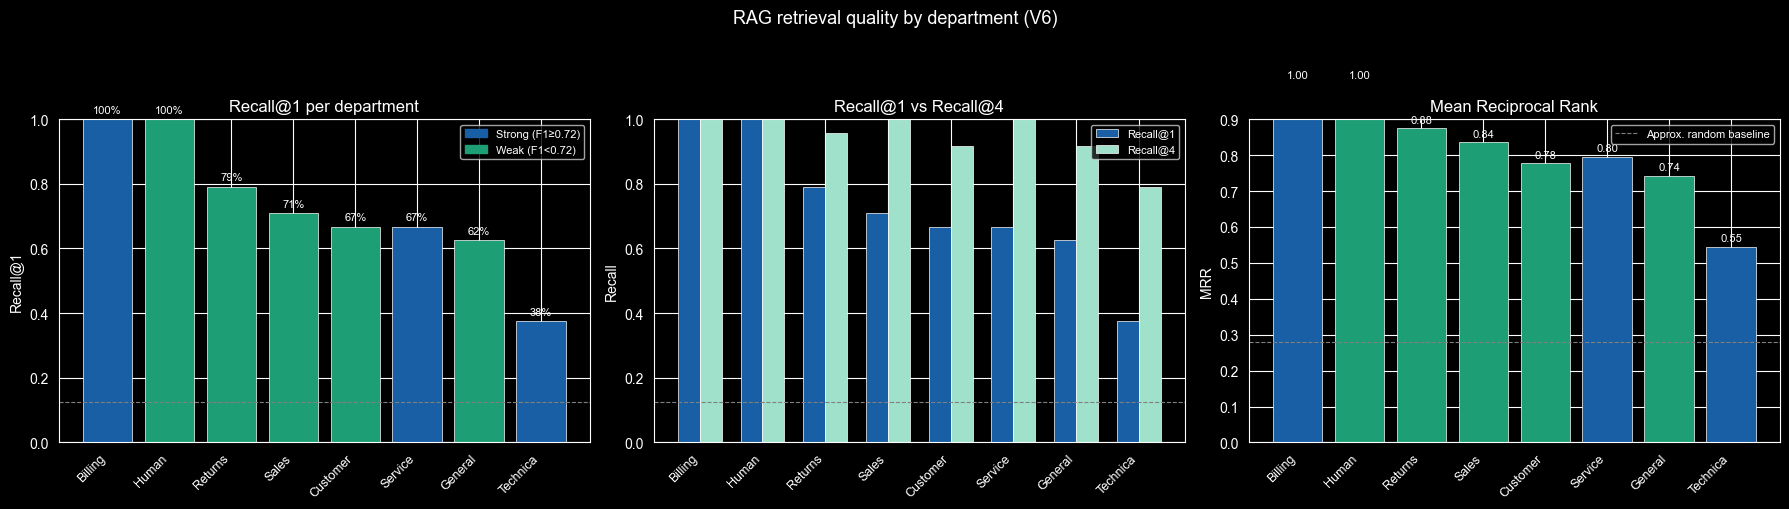

In [11]:
import matplotlib.patches as mpatches

depts_sorted = rag_df.groupby('true_dept')['recall_at_1'].mean().sort_values(ascending=False).index.tolist()
short = [d.replace(' and ', '\n').replace(' & ', '\n').split()[0][:8] for d in depts_sorted]

# V6 F1 scores from training eval — used to colour weak vs strong classes
DEPT_F1 = {
    'Billing and Payments':            0.99,
    'Customer Service':                0.60,
    'General Inquiry':                 0.64,
    'Human Resources':                 0.65,
    'Returns and Exchanges':           0.68,
    'Sales and Pre-Sales':             0.71,
    'Service Outages and Maintenance': 0.76,
    'Technical & IT Support':          0.78,
}
is_weak = [DEPT_F1.get(d, 1.0) < 0.72 for d in depts_sorted]
colors  = ['#1D9E75' if w else '#185FA5' for w in is_weak]

r1_  = rag_df.groupby('true_dept')['recall_at_1'].mean().reindex(depts_sorted).values
r4_  = rag_df.groupby('true_dept')['recall_at_4'].mean().reindex(depts_sorted).values
mrr_ = rag_df.groupby('true_dept')['mrr'].mean().reindex(depts_sorted).values
x, w = np.arange(len(depts_sorted)), 0.35

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('RAG retrieval quality by department (V6)', fontsize=13, y=1.01)

bars = axes[0].bar(x, r1_, color=colors, edgecolor='white', linewidth=0.5)
axes[0].axhline(1/8, color='grey', linestyle='--', lw=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels(short, rotation=45, ha='right', fontsize=9)
axes[0].set_ylim(0,1); axes[0].set_ylabel('Recall@1'); axes[0].set_title('Recall@1 per department')
for b,v in zip(bars,r1_): axes[0].text(b.get_x()+b.get_width()/2,v+0.02,f'{v*100:.0f}%',ha='center',fontsize=8)
axes[0].legend(handles=[mpatches.Patch(color='#185FA5',label='Strong (F1≥0.72)'),
                         mpatches.Patch(color='#1D9E75',label='Weak (F1<0.72)')],fontsize=8)

axes[1].bar(x-w/2, r1_, w, label='Recall@1', color='#185FA5', edgecolor='white', linewidth=0.5)
axes[1].bar(x+w/2, r4_, w, label='Recall@4', color='#9FE1CB', edgecolor='white', linewidth=0.5)
axes[1].axhline(1/8, color='grey', linestyle='--', lw=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(short, rotation=45, ha='right', fontsize=9)
axes[1].set_ylim(0,1); axes[1].set_ylabel('Recall')
axes[1].set_title('Recall@1 vs Recall@4'); axes[1].legend(fontsize=8)

bars3 = axes[2].bar(x, mrr_, color=colors, edgecolor='white', linewidth=0.5)
axes[2].axhline(0.28, color='grey', linestyle='--', lw=0.8, label='Approx. random baseline')
axes[2].set_xticks(x); axes[2].set_xticklabels(short, rotation=45, ha='right', fontsize=9)
axes[2].set_ylim(0,0.9); axes[2].set_ylabel('MRR')
axes[2].set_title('Mean Reciprocal Rank'); axes[2].legend(fontsize=8)
for b,v in zip(bars3,mrr_): axes[2].text(b.get_x()+b.get_width()/2,v+0.015,f'{v:.2f}',ha='center',fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'rag_retrieval_by_dept.png'),dpi=150,bbox_inches='tight')
plt.show()

---
## Section 3 — Full Pipeline: Accuracy + Latency

**Stage 1** always runs (Groq rewrite). **Stage 3 LLM** only runs when transformer confidence is below per-class threshold — otherwise fast path.

**TTFT** = Stage 1 latency — the first blocking LLM call.

**TPOT** = Stage 3 estimated latency / output tokens. Stage 3 generates a reasoning paragraph — TPOT varies with ticket complexity.

In [12]:
print('Measuring TTFT baseline (Stage 1 warm-up)...')
_t0 = time.perf_counter()
_ = _stage1(pipeline_df.iloc[0]['raw_text'])
TTFT_BASELINE = round(time.perf_counter() - _t0, 3)
print(f'TTFT baseline: {TTFT_BASELINE:.3f}s')
time.sleep(2.0)

# Per-class thresholds (V6)
DEPT_THRESHOLDS = {
    'Billing and Payments':            0.90,
    'Customer Service':                0.90,
    'General Inquiry':                 0.90,
    'Human Resources':                 0.90,
    'Returns and Exchanges':           0.90,
    'Sales and Pre-Sales':             0.90,
    'Service Outages and Maintenance': 0.90,
    'Technical & IT Support':          0.90,
}
PRIORITY_THRESHOLD = 0.99
print(len(pipeline_df))

Measuring TTFT baseline (Stage 1 warm-up)...
21:15:48  INFO      [stage1.rewriter]  Stage 1 — rewriting ticket (223 chars)
21:15:48  DEBUG     [stage1.rewriter]  Raw input: 'We recently had a poor experience with your onboarding process. The documentation was outdated and the assigned onboardi'
21:15:50  INFO      [stage1.rewriter]  Stage 1 done — subject: 'Issues with onboarding process and support'
21:15:50  DEBUG     [stage1.rewriter]  Urgency signals : ['poor experience', 'unresponsive', 'proper guidance']
21:15:50  DEBUG     [stage1.rewriter]  Tech keywords   : ['onboarding process', 'documentation', 'onboarding specialist']
21:15:50  DEBUG     [stage1.rewriter]  Explanation     : The likely department is customer onboarding.
21:15:50  DEBUG     [stage1.rewriter]  Cleaned text: 'We recently had a poor experience with your onboarding process. The documentation was outdated and the assigned onboardi'
TTFT baseline: 2.159s
192


In [17]:
from tqdm import tqdm
if os.path.exists(PIPELINE_RESULTS_PATH):
    _ex = pd.read_csv(PIPELINE_RESULTS_PATH)
    if len(_ex) > 0 and 'pred_dept' in _ex.columns:
        results_df = _ex
        print(f'Loaded cached pipeline results ({len(results_df)} rows)')
    else:
        os.remove(PIPELINE_RESULTS_PATH)

if not os.path.exists(PIPELINE_RESULTS_PATH):
    records, errors = [], 0
    for idx, row in tqdm(pipeline_df.iterrows(), total=len(pipeline_df)):
        try:
            t0  = time.perf_counter()
            res = route_ticket(
                row['raw_text'], None,
                model, tokenizer, queue_encoder, priority_encoder, device,
                embedder,
                faiss_index, bm25, all_chunks, cross_encoder,
                priority_index, priority_chunks)
            t_total          = round(time.perf_counter() - t0, 3)
            reasoning_tokens = max(len(res.reasoning.split()), 1)
            t_stage3_est     = max(t_total - TTFT_BASELINE - 0.05, 0.1)
            dept_thr         = DEPT_THRESHOLDS.get(res.transformer_dept, 0.70)
            fast_path        = (res.transformer_conf >= dept_thr and
                                res.priority_probs.get(res.priority, 0) >= PRIORITY_THRESHOLD)
            records.append({
                'true_dept'         : row['queue'],
                'true_priority'     : row['priority'],
                'pred_dept'         : res.department,
                'pred_priority'     : res.priority,
                'transformer_dept'  : res.transformer_dept,
                'transformer_conf'  : res.transformer_conf,
                'confidence'        : res.confidence,
                'llm_overrides_dept': int(res.department != res.transformer_dept),
                'fast_path'         : int(fast_path),
                't_total_s'         : t_total,
                'ttft_s'            : TTFT_BASELINE,
                'tpot_s'            : round(t_stage3_est / reasoning_tokens, 4),
                'reasoning_tokens'  : reasoning_tokens,
            })
        except Exception as e:
            if '429' in str(e) or 'rate_limit' in str(e).lower():
                pd.DataFrame(records).to_csv(PIPELINE_RESULTS_PATH, index=False)
                wait = 60
                print(f'\n⚠ Rate limit at row {idx} — waiting {wait}s then retrying...')
                time.sleep(wait)
                try:
                    t0  = time.perf_counter()
                    res = route_ticket(
                        row['raw_text'], None,
                        model, tokenizer, queue_encoder, priority_encoder, device,
                        embedder,
                        faiss_index, bm25, all_chunks, cross_encoder,
                        priority_index, priority_chunks)
                    t_total          = round(time.perf_counter() - t0, 3)
                    reasoning_tokens = max(len(res.reasoning.split()), 1)
                    t_stage3_est     = max(t_total - TTFT_BASELINE - 0.05, 0.1)
                    dept_thr         = DEPT_THRESHOLDS.get(res.transformer_dept, 0.70)
                    fast_path        = (res.transformer_conf >= dept_thr and
                                        res.priority_probs.get(res.priority, 0) >= PRIORITY_THRESHOLD)
                    records.append({
                        'true_dept': row['queue'], 'true_priority': row['priority'],
                        'pred_dept': res.department, 'pred_priority': res.priority,
                        'transformer_dept': res.transformer_dept, 'transformer_conf': res.transformer_conf,
                        'confidence': res.confidence, 'llm_overrides_dept': int(res.department != res.transformer_dept),
                        'fast_path': int(fast_path), 't_total_s': t_total, 'ttft_s': TTFT_BASELINE,
                        'tpot_s': round(t_stage3_est/reasoning_tokens, 4), 'reasoning_tokens': reasoning_tokens,
                    })
                except Exception as e2:
                    errors += 1
                    print(f'✗ Retry failed for row {idx}: {e2}')
                    records.append({'true_dept': row['queue'], 'true_priority': row['priority'],
                                    'pred_dept': 'ERROR', 'pred_priority': 'ERROR',
                                    'transformer_dept': '', 'transformer_conf': 0.0,
                                    'confidence': 'low', 'llm_overrides_dept': 0, 'fast_path': 0,
                                    't_total_s': None, 'ttft_s': None, 'tpot_s': None, 'reasoning_tokens': 0})
            else:
                errors += 1
                print(f'✗ Row {idx}: {e}')
                records.append({'true_dept': row['queue'], 'true_priority': row['priority'],
                                'pred_dept': 'ERROR', 'pred_priority': 'ERROR',
                                'transformer_dept': '', 'transformer_conf': 0.0,
                                'confidence': 'low', 'llm_overrides_dept': 0, 'fast_path': 0,
                                't_total_s': None, 'ttft_s': None, 'tpot_s': None, 'reasoning_tokens': 0})
        time.sleep(1.5)

    results_df = pd.DataFrame(records)
    results_df.to_csv(PIPELINE_RESULTS_PATH, index=False)
    print(f'Saved {len(results_df)} tickets ({errors} errors)')

if 'results_df' not in dir():
    results_df = pd.read_csv(PIPELINE_RESULTS_PATH)

  0%|          | 0/192 [00:00<?, ?it/s]

21:18:24  INFO      [router]  ============================================================
21:18:24  INFO      [router]  NEW TICKET (223 chars): 'We recently had a poor experience with your onboarding process. The documentatio'
21:18:24  INFO      [router]  ============================================================
21:18:24  INFO      [stage1.rewriter]  Stage 1 — rewriting ticket (223 chars)
21:18:24  DEBUG     [stage1.rewriter]  Raw input: 'We recently had a poor experience with your onboarding process. The documentation was outdated and the assigned onboardi'
21:18:25  INFO      [stage1.rewriter]  Stage 1 done — subject: 'Issues with onboarding process and support'
21:18:25  DEBUG     [stage1.rewriter]  Urgency signals : ['poor experience', 'unresponsive', 'follow up']
21:18:25  DEBUG     [stage1.rewriter]  Tech keywords   : ['onboarding process', 'documentation', 'onboarding specialist']
21:18:25  DEBUG     [stage1.rewriter]  Explanation     : The likely department is customer sup

  1%|          | 1/192 [00:04<14:14,  4.47s/it]

21:18:28  INFO      [router]  ============================================================
21:18:28  INFO      [router]  NEW TICKET (240 chars): 'Some product feature descriptions in your sales brochures reference capabilities'
21:18:28  INFO      [router]  ============================================================
21:18:28  INFO      [stage1.rewriter]  Stage 1 — rewriting ticket (240 chars)
21:18:28  DEBUG     [stage1.rewriter]  Raw input: 'Some product feature descriptions in your sales brochures reference capabilities from a previous version. The cybersecur'
21:18:30  INFO      [stage1.rewriter]  Stage 1 done — subject: 'Sales brochures reference outdated product features'
21:18:30  DEBUG     [stage1.rewriter]  Urgency signals : []
21:18:30  DEBUG     [stage1.rewriter]  Tech keywords   : ['cybersecurity', 'legacy interface', 'console']
21:18:30  DEBUG     [stage1.rewriter]  Explanation     : The likely department is marketing or sales.
21:18:30  DEBUG     [stage1.rewriter]  Cleane

  1%|          | 2/192 [00:10<16:34,  5.23s/it]

...

21:33:40  INFO      [router]  ============================================================
21:33:40  INFO      [router]  NEW TICKET (253 chars): 'The automated backup job for our PostgreSQL database has been failing intermitte'
21:33:40  INFO      [router]  ============================================================
21:33:40  INFO      [stage1.rewriter]  Stage 1 — rewriting ticket (253 chars)
21:33:40  DEBUG     [stage1.rewriter]  Raw input: 'The automated backup job for our PostgreSQL database has been failing intermittently. Approximately three of seven night'
21:33:42  INFO      [stage1.rewriter]  Stage 1 done — subject: 'Intermittent failures in PostgreSQL backup job'
21:33:42  DEBUG     [stage1.rewriter]  Urgency signals : ['failing intermittently', 'connection timeout errors']
21:33:42  DEBUG     [stage1.rewriter]  Tech keywords   : ['automated backup job', 'PostgreSQL database', 'nightly backups', 'log files', 'connection timeout', 'storage backend']
21:33:42  DEBUG     [stage1

 99%|█████████▉| 191/192 [15:21<00:04,  4.68s/it]

21:33:46  INFO      [router]  ============================================================
21:33:46  INFO      [router]  NEW TICKET (227 chars): 'The barcode scanners from our latest order have significantly shorter battery li'
21:33:46  INFO      [router]  ============================================================
21:33:46  INFO      [stage1.rewriter]  Stage 1 — rewriting ticket (227 chars)
21:33:46  DEBUG     [stage1.rewriter]  Raw input: 'The barcode scanners from our latest order have significantly shorter battery life than the same model we purchased prev'
21:33:47  INFO      [stage1.rewriter]  Stage 1 done — subject: 'Barcode scanners have reduced battery life'
21:33:47  DEBUG     [stage1.rewriter]  Urgency signals : ['defective batch', 'would like replacements']
21:33:47  DEBUG     [stage1.rewriter]  Tech keywords   : ['barcode scanners', 'battery life']
21:33:47  DEBUG     [stage1.rewriter]  Explanation     : This issue likely pertains to the hardware department.
21:33:47  DE

100%|██████████| 192/192 [15:26<00:00,  4.82s/it]

Saved 192 tickets (0 errors)


In [28]:
from sklearn.metrics import classification_report, confusion_matrix

clean = results_df[results_df['pred_dept'] != 'ERROR'].copy()
clean['dept_correct']  = (clean['pred_dept']       == clean['true_dept']).astype(int)
clean['prio_correct']  = (clean['pred_priority']   == clean['true_priority']).astype(int)
clean['trans_correct'] = (clean['transformer_dept'] == clean['true_dept']).astype(int)

print('=' * 60)
print('FULL PIPELINE END-TO-END (V6)')
print('=' * 60)
print(f'Department Accuracy : {clean["dept_correct"].mean()*100:.1f}%')
print(f'Priority   Accuracy : {clean["prio_correct"].mean()*100:.1f}%')
print(f'Total tickets       : {len(clean)}')
print()

overrides  = clean[clean['llm_overrides_dept'] == 1]
agreements = clean[clean['llm_overrides_dept'] == 0]
print()
print(f'LLM overrode transformer    : {len(overrides)} tickets ({len(overrides)/max(len(clean),1)*100:.1f}%)')
if len(overrides) > 0:
    trans_on_ov = overrides['trans_correct'].mean()
    llm_on_ov   = overrides['dept_correct'].mean()
    delta       = (llm_on_ov - trans_on_ov) * 100
    print(f'  Transformer accuracy on overridden tickets : {trans_on_ov*100:.1f}%')
    print(f'  LLM final accuracy on overridden tickets   : {llm_on_ov*100:.1f}%')
    print(f'  LLM override improvement                   : {delta:+.1f}pp')

print()
print('DEPARTMENT CLASSIFICATION REPORT (full pipeline):')
print(classification_report(clean['true_dept'], clean['pred_dept'], zero_division=0))
print('PRIORITY CLASSIFICATION REPORT (full pipeline):')
print(classification_report(clean['true_priority'], clean['pred_priority'], zero_division=0))

FULL PIPELINE END-TO-END (V6)
Department Accuracy : 81.8%
Priority   Accuracy : 85.4%
Total tickets       : 192


LLM overrode transformer    : 71 tickets (37.0%)
  Transformer accuracy on overridden tickets : 9.9%
  LLM final accuracy on overridden tickets   : 69.0%
  LLM override improvement                   : +59.2pp

DEPARTMENT CLASSIFICATION REPORT (full pipeline):
                                 precision    recall  f1-score   support

           Billing and Payments       1.00      1.00      1.00        24
               Customer Service       1.00      0.71      0.83        24
                General Inquiry       0.65      0.54      0.59        24
                Human Resources       0.96      1.00      0.98        24
          Returns and Exchanges       1.00      0.75      0.86        24
            Sales and Pre-Sales       0.65      1.00      0.79        24
Service Outages and Maintenance       0.75      0.88      0.81        24
         Technical & IT Support       0.7

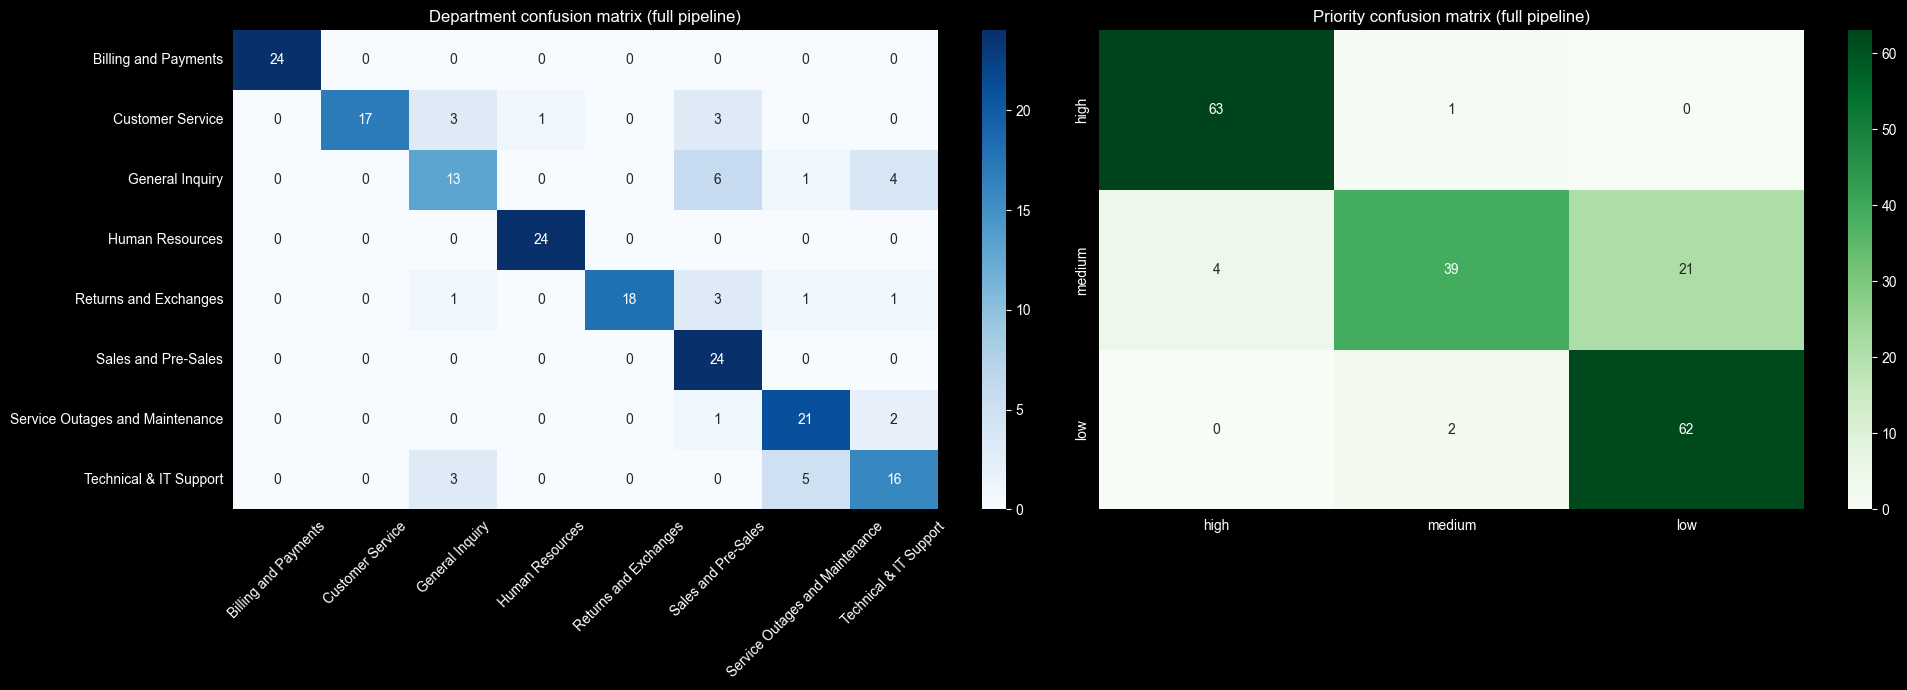

In [29]:
dept_labels = sorted(clean['true_dept'].unique())
prio_labels = ['high', 'medium', 'low']

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
sns.heatmap(confusion_matrix(clean['true_dept'], clean['pred_dept'], labels=dept_labels),
    annot=True, fmt='d', cmap='Blues', xticklabels=dept_labels, yticklabels=dept_labels, ax=axes[0])
axes[0].set_title('Department confusion matrix (full pipeline)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(confusion_matrix(clean['true_priority'], clean['pred_priority'], labels=prio_labels),
    annot=True, fmt='d', cmap='Greens', xticklabels=prio_labels, yticklabels=prio_labels, ax=axes[1])
axes[1].set_title('Priority confusion matrix (full pipeline)', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'pipeline_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

LATENCY METRICS
TTFT — Stage 1 rewrite (first blocking Groq call):
  Measured baseline : 2.159s

End-to-end latency (all stages):
  Mean   : 3.318s
  Median : 3.311s
  P90    : 3.999s

TPOT — Stage 3 output (reasoning paragraph):
  Mean   : 0.0176s/token
  Median : 0.0178s/token
  Avg reasoning tokens : 63
  Reference: human reading ~0.125-0.167s/token (6-8 tokens/s)

Fast path (no Stage 3 LLM): 0.0% of tickets


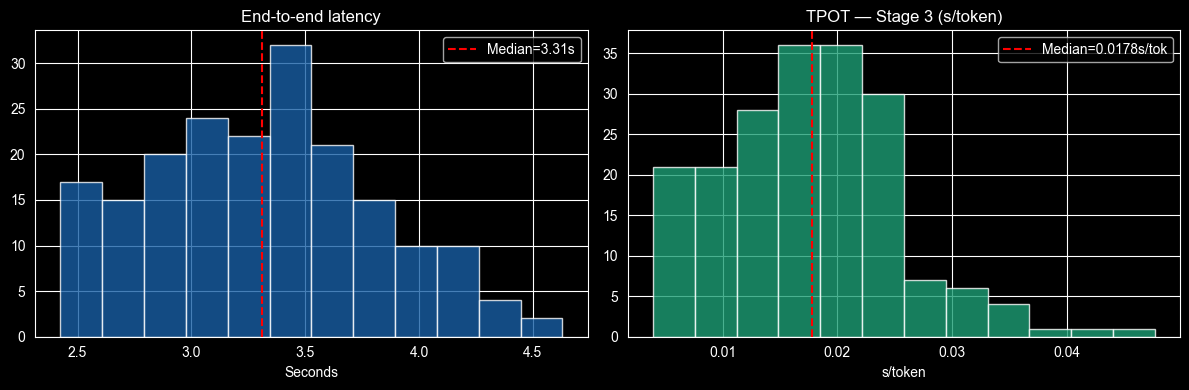

In [30]:
lat = clean[clean['t_total_s'].notna()]

print('=' * 60)
print('LATENCY METRICS')
print('=' * 60)
print(f'TTFT — Stage 1 rewrite (first blocking Groq call):')
print(f'  Measured baseline : {TTFT_BASELINE:.3f}s')
print()
print(f'End-to-end latency (all stages):')
print(f'  Mean   : {lat["t_total_s"].mean():.3f}s')
print(f'  Median : {lat["t_total_s"].median():.3f}s')
print(f'  P90    : {lat["t_total_s"].quantile(0.9):.3f}s')
print()
tpot_vals = lat[lat['tpot_s'].notna()]['tpot_s']
print(f'TPOT — Stage 3 output (reasoning paragraph):')
print(f'  Mean   : {tpot_vals.mean():.4f}s/token')
print(f'  Median : {tpot_vals.median():.4f}s/token')
print(f'  Avg reasoning tokens : {lat["reasoning_tokens"].mean():.0f}')
print(f'  Reference: human reading ~0.125-0.167s/token (6-8 tokens/s)')
print()
print(f'Fast path (no Stage 3 LLM): {clean["fast_path"].mean()*100:.1f}% of tickets')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
lat['t_total_s'].hist(bins=12, ax=axes[0], color='#185FA5', alpha=0.8)
axes[0].axvline(lat['t_total_s'].median(), color='red', linestyle='--',
                label=f'Median={lat["t_total_s"].median():.2f}s')
axes[0].set_title('End-to-end latency'); axes[0].set_xlabel('Seconds'); axes[0].legend()

tpot_vals.hist(bins=12, ax=axes[1], color='#1D9E75', alpha=0.8)
axes[1].axvline(tpot_vals.median(), color='red', linestyle='--',
                label=f'Median={tpot_vals.median():.4f}s/tok')
axes[1].set_title('TPOT — Stage 3 (s/token)'); axes[1].set_xlabel('s/token'); axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'latency_distributions.png'),dpi=150,bbox_inches='tight')
plt.show()

In [31]:
# ── Section 4: AI-as-a-Judge ──────────────────────────────────────────────
#
# Why AI-as-a-judge:
#   Standard metrics (accuracy, F1) only tell you IF the answer is correct.
#   They cannot evaluate WHY — whether the reasoning cited real evidence,
#   whether Stage 1 rewrote faithfully, whether Stage 3 used transformer
#   confidence and RAG chunks correctly to justify its decision.
#   The judge evaluates these dimensions independently using custom rubrics.
#
#   Rubric 1 — Stage 1 rewrite quality
#   Rubric 2 — Stage 3 reasoning quality (slow path only)
#   Rubric 3 — Overall routing quality
#
# res.cleaned_text and res.reasoning come directly from RoutingResult —
# no extra Stage 1 call needed.

REWRITE_RUBRIC = """You are evaluating the quality of a customer support ticket rewriter.

ORIGINAL TICKET:
{original}

REWRITTEN TICKET:
{rewritten}

Score on a scale of 1 to 3:
1 = Meaning changed, key details lost, or department-specific vocabulary injected that was not in the original
2 = Meaning mostly preserved but rewrite is verbose, awkward, or adds minor assumptions not in original
3 = Meaning fully preserved, clean professional rewrite, no vocabulary injection, all key facts retained

Respond with ONLY a JSON object: {{"score": <1|2|3>, "reason": "<one sentence>"}}"""


REASONING_RUBRIC = """You are evaluating whether an AI routing system justified its decision with real evidence.

TICKET:
{ticket}

PREDICTED DEPARTMENT: {pred_dept}
PREDICTED PRIORITY: {pred_priority}
REASONING PROVIDED:
{reasoning}

Score on a scale of 1 to 3:
1 = Reasoning is vague or fabricated — does not cite transformer confidence scores or RAG evidence
2 = Broadly correct but generic — mentions sources without specific values or concrete evidence
3 = Cites specific evidence: transformer confidence percentage, RAG chunk department, priority criteria — and explains clearly why they support this decision

Respond with ONLY a JSON object: {{"score": <1|2|3>, "reason": "<one sentence>"}}"""


ROUTING_RUBRIC = """You are evaluating the overall quality of a support ticket routing decision.

TICKET:
{ticket}

PREDICTED DEPARTMENT: {pred_dept}  |  TRUE DEPARTMENT: {true_dept}
PREDICTED PRIORITY:   {pred_prio}  |  TRUE PRIORITY:   {true_prio}
REASONING: {reasoning}

Score on a scale of 1 to 3:
1 = Department or priority wrong, or reasoning does not support the decision made
2 = Department correct but priority questionable, or reasoning is weak and does not cite specific evidence
3 = Both department and priority correct, reasoning cites specific evidence from the ticket that justifies the decision

Respond with ONLY a JSON object: {{"score": <1|2|3>, "reason": "<one sentence>"}}"""


from openai import OpenAI

openai_client = OpenAI(api_key=os.getenv('OPENAI_API_KEY'))
JUDGE_MODEL = 'gpt-5.2'

def judge_call(prompt, retries=3):
    for attempt in range(retries):
        try:
            resp = openai_client.chat.completions.create(
                model=JUDGE_MODEL,
                messages=[{'role': 'user', 'content': prompt}],
                temperature=0.0,
            )
            raw = resp.choices[0].message.content.strip()
            m = re.search(r'\{.*?\}', raw, re.DOTALL)
            if m:
                return json.loads(m.group())
            return {'score': 0, 'reason': f'no JSON: {raw[:80]}'}
        except Exception as e:
            if 'rate_limit' in str(e).lower() and attempt < retries - 1:
                print(f'    Rate limit — waiting 20s (attempt {attempt+1})')
                time.sleep(20)
                continue
            return {'score': 0, 'reason': f'error: {e}'}
    return {'score': 0, 'reason': 'max retries exceeded'}
print('Judge rubrics and helper defined')

Judge rubrics and helper defined


In [32]:
# ── Run judge on pipeline_df sample ───────────────────────────────────────
# Uses 10 tickets — balanced across fast and slow path.
# Each ticket: 1 pipeline call + up to 3 judge calls = 4 Groq calls max.
# res.cleaned_text used throughout — no duplicate Stage 1 call.

if os.path.exists(JUDGE_RESULTS_PATH):
    _ej = pd.read_csv(JUDGE_RESULTS_PATH)
    if len(_ej) > 0 and 'rewrite_score' in _ej.columns:
        judge_df = _ej
        print(f'✓ Loaded cached judge results ({len(judge_df)} rows)')
    else:
        os.remove(JUDGE_RESULTS_PATH)

if not os.path.exists(JUDGE_RESULTS_PATH):
    judge_sample=results_df

    print(f'Running AI judge on {len(judge_sample)} tickets...')
    jrecords = []

    for idx, row in tqdm(judge_sample.iterrows(), total=len(judge_sample)):
        raw_text  = row['raw_text'] if 'raw_text' in row else pipeline_df.loc[
            pipeline_df['queue'] == row['true_dept']
            ].iloc[0]['raw_text']

        try:
            # Single pipeline call — cleaned_text and reasoning in result
            res = route_ticket(
                raw_text, None,
                model, tokenizer, queue_encoder, priority_encoder, device,
                embedder,
                faiss_index, bm25, all_chunks, cross_encoder,
                priority_index, priority_chunks
            )
            time.sleep(1.0)

            is_slow_path = res.rag_used if hasattr(res, 'rag_used') else (res.reasoning != '')

            # Rubric 1: Stage 1 rewrite quality
            r1 = judge_call(REWRITE_RUBRIC.format(
                original=raw_text[:500],
                rewritten=res.cleaned_text[:500]
            ))
            time.sleep(1.0)

            # Rubric 2: Stage 3 reasoning quality — only meaningful on slow path
            # Fast path: transformer was confident, LLM reasoning not invoked
            if is_slow_path:
                r2 = judge_call(REASONING_RUBRIC.format(
                    ticket=res.cleaned_text[:400],
                    pred_dept=res.department,
                    pred_priority=res.priority,
                    reasoning=res.reasoning[:500]
                ))
                time.sleep(1.0)
            else:
                r2 = {
                    'score' : None,
                    'reason': 'fast path — transformer confident, Stage 3 LLM not invoked'
                }

            # Rubric 3: Overall routing quality (all tickets)
            r3 = judge_call(ROUTING_RUBRIC.format(
                ticket=res.cleaned_text[:400],
                pred_dept=res.department,  true_dept=row['true_dept'],
                pred_prio=res.priority,    true_prio=row['true_priority'],
                reasoning=res.reasoning[:500]
            ))
            time.sleep(1.0)

            jrecords.append({
                'true_dept'        : row['true_dept'],
                'true_priority'    : row['true_priority'],
                'pred_dept'        : res.department,
                'pred_priority'    : res.priority,
                'dept_correct'     : int(res.department == row['true_dept']),
                'prio_correct'     : int(res.priority   == row['true_priority']),
                'fast_path'        : int(not is_slow_path),
                'rewrite_score'    : r1.get('score'),
                'rewrite_reason'   : r1.get('reason'),
                'reasoning_score'  : r2.get('score'),
                'reasoning_reason' : r2.get('reason'),
                'routing_score'    : r3.get('score'),
                'routing_reason'   : r3.get('reason'),
            })

        except Exception as e:
            print(f'✗ Row {idx}: {e}')

        time.sleep(1.5)

    judge_df = pd.DataFrame(jrecords)
    judge_df.to_csv(JUDGE_RESULTS_PATH, index=False)
    print(f'✓ Judge complete — {len(judge_df)} tickets saved')

if 'judge_df' not in dir():
    judge_df = pd.read_csv(JUDGE_RESULTS_PATH)

Running AI judge on 192 tickets...


  0%|          | 0/192 [00:00<?, ?it/s]

21:48:29  INFO      [router]  ============================================================
21:48:29  INFO      [router]  NEW TICKET (223 chars): 'We recently had a poor experience with your onboarding process. The documentatio'
21:48:29  INFO      [router]  ============================================================
21:48:29  INFO      [stage1.rewriter]  Stage 1 — rewriting ticket (223 chars)
21:48:29  DEBUG     [stage1.rewriter]  Raw input: 'We recently had a poor experience with your onboarding process. The documentation was outdated and the assigned onboardi'
21:48:30  INFO      [stage1.rewriter]  Stage 1 done — subject: 'Issues with onboarding process and support'
21:48:30  DEBUG     [stage1.rewriter]  Urgency signals : ['poor experience', 'unresponsive', 'follow up']
21:48:30  DEBUG     [stage1.rewriter]  Tech keywords   : ['onboarding process', 'documentation', 'onboarding specialist']
21:48:30  DEBUG     [stage1.rewriter]  Explanation     : The likely department is customer sup

  1%|          | 1/192 [00:12<41:00, 12.88s/it]

21:48:42  INFO      [router]  ============================================================
21:48:42  INFO      [router]  NEW TICKET (240 chars): 'Some product feature descriptions in your sales brochures reference capabilities'
21:48:42  INFO      [router]  ============================================================
21:48:42  INFO      [stage1.rewriter]  Stage 1 — rewriting ticket (240 chars)
21:48:42  DEBUG     [stage1.rewriter]  Raw input: 'Some product feature descriptions in your sales brochures reference capabilities from a previous version. The cybersecur'
21:48:43  INFO      [stage1.rewriter]  Stage 1 done — subject: 'Sales brochures reference outdated product features'
21:48:43  DEBUG     [stage1.rewriter]  Urgency signals : ['Might be worth refreshing']
21:48:43  DEBUG     [stage1.rewriter]  Tech keywords   : ['cybersecurity', 'legacy interface', 'console']
21:48:43  DEBUG     [stage1.rewriter]  Explanation     : This likely pertains to the marketing department.
21:48:43  DEB

...

22:32:08  INFO      [router]  ============================================================
22:32:08  INFO      [router]  NEW TICKET (246 chars): 'The VPN concentrator serving our entire remote workforce has failed and cannot b'
22:32:08  INFO      [router]  ============================================================
22:32:08  INFO      [stage1.rewriter]  Stage 1 — rewriting ticket (246 chars)
22:32:08  DEBUG     [stage1.rewriter]  Raw input: 'The VPN concentrator serving our entire remote workforce has failed and cannot be restarted. Approximately 200 remote us'
22:32:10  INFO      [stage1.rewriter]  Stage 1 done — subject: 'VPN concentrator failure affecting remote workforce'
22:32:10  DEBUG     [stage1.rewriter]  Urgency signals : ['failed', 'cannot be restarted', 'lost access', 'need restored immediately']
22:32:10  DEBUG     [stage1.rewriter]  Tech keywords   : ['VPN concentrator', 'remote workforce', 'internal systems', 'network device']
22:32:10  DEBUG     [stage1.rewriter]  Exp

 99%|█████████▉| 191/192 [43:52<00:13, 13.57s/it]

22:32:22  INFO      [router]  ============================================================
22:32:22  INFO      [router]  NEW TICKET (229 chars): 'Before placing a repeat order, could you confirm whether the IoT sensor model ha'
22:32:22  INFO      [router]  ============================================================
22:32:22  INFO      [stage1.rewriter]  Stage 1 — rewriting ticket (229 chars)
22:32:22  DEBUG     [stage1.rewriter]  Raw input: 'Before placing a repeat order, could you confirm whether the IoT sensor model has been updated since our last purchase? '
22:32:23  INFO      [stage1.rewriter]  Stage 1 done — subject: 'Inquiry about IoT sensor model update'
22:32:23  DEBUG     [stage1.rewriter]  Urgency signals : []
22:32:23  DEBUG     [stage1.rewriter]  Tech keywords   : ['IoT sensor', 'product compatibility']
22:32:23  DEBUG     [stage1.rewriter]  Explanation     : The likely department is product information or sales.
22:32:23  DEBUG     [stage1.rewriter]  Cleaned text: 'Coul

100%|██████████| 192/192 [44:07<00:00, 13.79s/it]

✓ Judge complete — 192 tickets saved


AI-AS-A-JUDGE RESULTS  (1=poor  2=acceptable  3=excellent)
Stage 1 rewrite quality  : mean=3.00  dist={3: 192}
Stage 3 reasoning quality: mean=2.27  dist={1: 4, 2: 133, 3: 55}

Fast path (transformer confident, no LLM): 0 tickets
Slow path (RAG + LLM invoked)            : 192 tickets
(Reasoning rubric only scored on slow path — LLM not invoked on fast path)

Sample judge reasoning:

── Rewrite quality ──
  Score 3: The rewritten ticket is identical to the original, preserving all meaning and key details without adding assumptions or new vocabulary.

── Reasoning quality ──
  Score 2: It cites a specific transformer confidence (98.0%) and gives a generic priority rationale, but provides no RAG chunk evidence and the department choice is not clearly supported by concrete ticket cues.
  Score 3: It cites a specific transformer confidence score (99.7%) and ties the low priority to concrete ticket evidence (general future-reference billing question with no urgency), clearly supporting both 

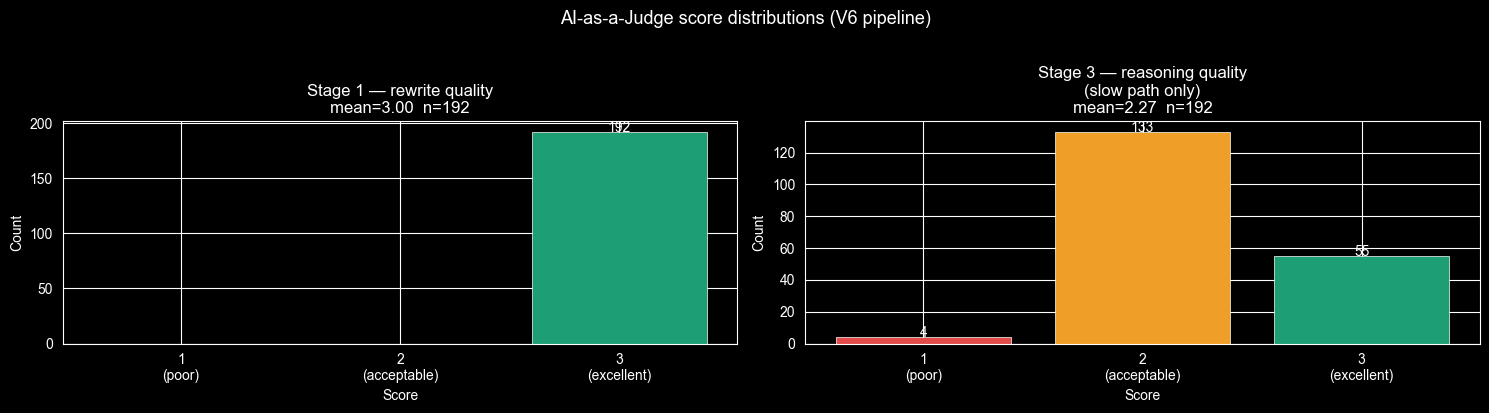

✓ Saved judge_scores.png


In [36]:
# ── Judge results summary + plots ─────────────────────────────────────────
numeric = judge_df.copy()
for col in ['rewrite_score', 'reasoning_score']:
    numeric[col] = pd.to_numeric(numeric[col], errors='coerce')

print('=' * 60)
print('AI-AS-A-JUDGE RESULTS  (1=poor  2=acceptable  3=excellent)')
print('=' * 60)
for col, label in [
    ('rewrite_score',   'Stage 1 rewrite quality  '),
    ('reasoning_score', 'Stage 3 reasoning quality'),
]:
    vals = numeric[col].dropna()
    if len(vals):
        dist = vals.value_counts().sort_index().to_dict()
        print(f'{label}: mean={vals.mean():.2f}  dist={dist}')

fast_n = (judge_df['fast_path'] == 1).sum()
slow_n = (judge_df['fast_path'] == 0).sum()
print(f'\nFast path (transformer confident, no LLM): {fast_n} tickets')
print(f'Slow path (RAG + LLM invoked)            : {slow_n} tickets')
print(f'(Reasoning rubric only scored on slow path — LLM not invoked on fast path)')

# Sample reasoning per score level
print('\nSample judge reasoning:')
for col, rcol, label in [
    ('rewrite_score',   'rewrite_reason',   'Rewrite quality'),
    ('reasoning_score', 'reasoning_reason', 'Reasoning quality'),
]:
    print(f'\n── {label} ──')
    for _, r in numeric[[col, rcol]].dropna(subset=[col]).drop_duplicates(col).iterrows():
        score = r[col]
        reason = r[rcol]
        if pd.notna(score) and pd.notna(reason):
            print(f'  Score {int(score)}: {reason}')

# Score distribution bar charts
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
for ax, col, title in [
    (axes[0], 'rewrite_score',   'Stage 1 — rewrite quality'),
    (axes[1], 'reasoning_score', 'Stage 3 — reasoning quality\n(slow path only)'),
]:
    vals = numeric[col].dropna()
    if len(vals):
        counts = vals.value_counts().sort_index().reindex([1, 2, 3], fill_value=0)
        bars = ax.bar([1, 2, 3], counts.values, color=['#E24B4A', '#EF9F27', '#1D9E75'],
                      edgecolor='white', linewidth=0.5)
        ax.set_title(f'{title}\nmean={vals.mean():.2f}  n={int(len(vals))}')
        ax.set_xlabel('Score'); ax.set_ylabel('Count')
        ax.set_xticks([1, 2, 3])
        ax.set_xticklabels(['1\n(poor)', '2\n(acceptable)', '3\n(excellent)'])
        for bar, count in zip(bars, counts.values):
            if count > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                        str(count), ha='center', fontsize=10)

plt.suptitle('AI-as-a-Judge score distributions (V6 pipeline)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'judge_scores.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved judge_scores.png')

In [37]:
# ── Final summary ──────────────────────────────────────────────────────────
print('=' * 65)
print('EVALUATION SUMMARY — V6 pipeline')
print('=' * 65)

print('\n── Sec 1: Transformer standalone (Stage 2a) ──')
print(f'  Dept  Accuracy={dept_acc*100:.1f}%  F1={dept_f1*100:.1f}%  ECE={dept_ece:.4f}')
print(f'  Prio  Accuracy={prio_acc*100:.1f}%  F1={prio_f1*100:.1f}%  ECE={prio_ece:.4f}')

print('\n── Sec 2: RAG retrieval (Stage 2b) ──')
print(f'  Dept  Recall@1={rag_df["recall_at_1"].mean()*100:.1f}%  '
      f'Recall@4={rag_df["recall_at_4"].mean()*100:.1f}%  MRR={rag_df["mrr"].mean():.3f}')
print(f'  Prio  Section accuracy={rag_df["prio_correct"].mean()*100:.1f}%  (random baseline 33.3%)')

print('\n── Sec 3: Full pipeline ──')
if 'clean' in dir() and len(clean):
    print(f'  Dept  Accuracy={clean["dept_correct"].mean()*100:.1f}%')
    print(f'  Prio  Accuracy={clean["prio_correct"].mean()*100:.1f}%')
    print(f'  Fast path rate={clean["fast_path"].mean()*100:.1f}% of tickets')
    # if 'delta' in dir():
    #     print(f'  LLM override improvement={delta:+.1f}pp dept accuracy')
    _lat = clean[clean['t_total_s'].notna()]
    print(f'  TTFT={TTFT_BASELINE:.3f}s  E2E median={_lat["t_total_s"].median():.3f}s  '
          f'P90={_lat["t_total_s"].quantile(0.9):.3f}s')
    _tp = _lat[_lat['tpot_s'].notna()]['tpot_s']
    if len(_tp):
        print(f'  TPOT median={_tp.median():.4f}s/token (Stage 3, slow path)')

print('\n── Sec 4: AI-as-a-judge ──')
if 'numeric' in dir() and len(numeric):
    for col, label in [
        ('rewrite_score',   'Stage 1 rewrite   (1-3)'),
        ('reasoning_score', 'Stage 3 reasoning (1-3)'),
    ]:
        v = numeric[col].dropna()
        if len(v): print(f'  {label}: {v.mean():.2f}')

print(f'\nOutputs saved to: {OUT_DIR}')

EVALUATION SUMMARY — V6 pipeline

── Sec 1: Transformer standalone (Stage 2a) ──
  Dept  Accuracy=58.9%  F1=52.4%  ECE=0.1578
  Prio  Accuracy=39.1%  F1=29.0%  ECE=0.4078

── Sec 2: RAG retrieval (Stage 2b) ──
  Dept  Recall@1=72.9%  Recall@4=94.8%  MRR=0.822
  Prio  Section accuracy=57.3%  (random baseline 33.3%)

── Sec 3: Full pipeline ──
  Dept  Accuracy=81.8%
  Prio  Accuracy=85.4%
  Fast path rate=0.0% of tickets
  TTFT=2.159s  E2E median=3.311s  P90=3.999s
  TPOT median=0.0178s/token (Stage 3, slow path)

── Sec 4: AI-as-a-judge ──
  Stage 1 rewrite   (1-3): 3.00
  Stage 3 reasoning (1-3): 2.27

Outputs saved to: /Users/avani/IdeaProjects/customer-support-management/outputs/evaluation
